# 2D Poisson FEM — LS-QUBO 缩放实验 (4×4 子域)
## 固定子域大小 5×5 单元, 4×4 子域配置
DD-QUBO: 静态凝聚 + 每子域独立 CIM 求解 + 全局边界经典求解

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time, warnings, json, os
warnings.filterwarnings('ignore')

import kaiwu as kw
kw.common.CheckpointManager.save_dir = '/tmp'

# ===== 配置 =====
Lx, Ly = 3.0, 2.0
nblk_x, nblk_y = 4, 4
ne_per_blk_x, ne_per_blk_y = 5, 5
BIT_WIDTH = 8
OUTPUT_DIR = 'D:/QPDE/experime2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('模块加载完成')
print(f'子域: {nblk_x}x{nblk_y}={nblk_x*nblk_y}, 每子域单元: {ne_per_blk_x}x{ne_per_blk_y}, 位宽: {BIT_WIDTH}')

模块加载完成
子域: 4x4=16, 每子域单元: 5x5, 位宽: 8


In [2]:
# ===== 生成网格和单元 =====
nx = nblk_x * ne_per_blk_x
ny = nblk_y * ne_per_blk_y
Nx, Ny = nx + 1, ny + 1
n_nodes = Nx * Ny

x_coords = np.linspace(0, Lx, Nx)
y_coords = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')
nodes = np.vstack([X.ravel(), Y.ravel()]).T

elements = []
for j in range(ny):
    for i in range(nx):
        n0 = j * Nx + i
        n1 = n0 + 1
        n2 = n0 + Nx + 1
        n3 = n0 + Nx
        elements.append([n0, n1, n2, n3])
elements = np.array(elements)

print(f'节点数: {n_nodes}, 单元数: {len(elements)}')

节点数: 441, 单元数: 400


In [3]:
# ===== 解析解和源项 =====
def u_exact(x, y):
    return x * y * np.cos(2 * np.pi * x / 3.0)

def source_term(x, y):
    u_xx = - (2 * np.pi / 3.0)**2 * x * y * np.cos(2 * np.pi * x / 3.0) \
           - (4 * np.pi / 3.0) * y * np.sin(2 * np.pi * x / 3.0)
    u_yy = 0.0
    return -(u_xx + u_yy)

u_exact_all = np.array([u_exact(x, y) for (x, y) in nodes])
print(f'精确解范围: [{u_exact_all.min():.4f}, {u_exact_all.max():.4f}]')

精确解范围: [-3.1385, 6.0000]


In [6]:
# ===== 单元刚度矩阵和载荷向量 (2×2 高斯积分) =====
def gauss_points_2x2():
    sqrt3 = np.sqrt(3.0)
    xi_vals = [-1.0/sqrt3, 1.0/sqrt3]
    w = [1.0, 1.0]
    return [(xi_vals[i], xi_vals[j], w[i]*w[j]) for i in range(2) for j in range(2)]

def shape_functions(xi, eta):
    N = np.array([
        (1-xi)*(1-eta), (1+xi)*(1-eta),
        (1+xi)*(1+eta), (1-xi)*(1+eta)
    ]) / 4.0
    dN_dxi = np.array([
        [-(1-eta), -(1-xi)], [(1-eta), -(1+xi)],
        [(1+eta), (1+xi)], [-(1+eta), (1-xi)]
    ]) / 4.0
    return N, dN_dxi

def elem_stiffness_and_load(xe, ye, source_func):
    Ke = np.zeros((4, 4))
    Fe = np.zeros(4)
    for xi, eta, w in gauss_points_2x2():
        N, dN_dxi = shape_functions(xi, eta)
        J = np.zeros((2, 2))
        for i in range(4):
            J[0, 0] += dN_dxi[i, 0] * xe[i]
            J[0, 1] += dN_dxi[i, 0] * ye[i]
            J[1, 0] += dN_dxi[i, 1] * xe[i]
            J[1, 1] += dN_dxi[i, 1] * ye[i]
        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)
        dN_dxy = np.array([invJ @ dN_dxi[i] for i in range(4)])
        for i in range(4):
            for j in range(4):
                Ke[i, j] += (dN_dxy[i, 0]*dN_dxy[j, 0] + dN_dxy[i, 1]*dN_dxy[j, 1]) * detJ * w
        xp = np.dot(N, xe)
        yp = np.dot(N, ye)
        Fe += N * source_func(xp, yp) * detJ * w
    return Ke, Fe

print('FEM kernel 已定义')

FEM kernel 已定义


In [7]:
# ===== 分块：将单元分配给各子域 =====
blk_w = Lx / nblk_x
blk_h = Ly / nblk_y

def get_subdomain_id(cx, cy):
    ix = min(int(np.floor(cx / blk_w)), nblk_x - 1)
    iy = min(int(np.floor(cy / blk_h)), nblk_y - 1)
    return ix, iy

elem_centers = []
for elem in elements:
    coords = nodes[elem]
    elem_centers.append((np.mean(coords[:, 0]), np.mean(coords[:, 1])))

subdomains = [{'elements': [], 'nodes': set()} for _ in range(nblk_x * nblk_y)]
for idx_e, elem in enumerate(elements):
    cx, cy = elem_centers[idx_e]
    ix, iy = get_subdomain_id(cx, cy)
    sid = iy * nblk_x + ix
    subdomains[sid]['elements'].append(elem)
    for n in elem:
        subdomains[sid]['nodes'].add(n)

for sd in subdomains:
    sd['nodes'] = list(sd['nodes'])

# ===== 边界判断 =====
def is_node_on_subdomain_boundary(node_coord, blk_x, blk_y):
    x, y = node_coord
    left = blk_x * blk_w
    right = (blk_x + 1) * blk_w
    bottom = blk_y * blk_h
    top = (blk_y + 1) * blk_h
    eps = 1e-12
    return (abs(x - left) < eps or abs(x - right) < eps or
            abs(y - bottom) < eps or abs(y - top) < eps)

def is_on_global_boundary(gid):
    x, y = nodes[gid]
    eps = 1e-12
    return (abs(x) < eps or abs(x - Lx) < eps or
            abs(y) < eps or abs(y - Ly) < eps)

print(f'子域数: {len(subdomains)}')

子域数: 16


In [8]:
# ===== 静态凝聚 =====
global_boundary_nodes_set = set()
subdomain_data = []

for sid, sd in enumerate(subdomains):
    blk_ix = sid % nblk_x
    blk_iy = sid // nblk_x
    local_nodes = sd['nodes']
    n_local = len(local_nodes)
    global2local = {gid: i for i, gid in enumerate(local_nodes)}

    K_local = np.zeros((n_local, n_local))
    F_local = np.zeros(n_local)
    for elem in sd['elements']:
        conn = elem
        local_conn = [global2local[gid] for gid in conn]
        xe = nodes[conn, 0]
        ye = nodes[conn, 1]
        Ke, Fe = elem_stiffness_and_load(xe, ye, source_term)
        for a, la in enumerate(local_conn):
            F_local[la] += Fe[a]
            for b, lb in enumerate(local_conn):
                K_local[la, lb] += Ke[a, b]

    is_boundary = np.zeros(n_local, dtype=bool)
    for i, gid in enumerate(local_nodes):
        is_boundary[i] = is_node_on_subdomain_boundary(nodes[gid], blk_ix, blk_iy)

    idx_b = np.where(is_boundary)[0]
    idx_i = np.where(~is_boundary)[0]

    if len(idx_i) > 0:
        K_ii = K_local[np.ix_(idx_i, idx_i)]
        K_ib = K_local[np.ix_(idx_i, idx_b)]
        K_bi = K_local[np.ix_(idx_b, idx_i)]
        K_bb = K_local[np.ix_(idx_b, idx_b)]
        F_i = F_local[idx_i]
        F_b = F_local[idx_b]

        inv_K_ii = np.linalg.inv(K_ii)
        S = K_bb - K_bi @ inv_K_ii @ K_ib
        g = F_b - K_bi @ (inv_K_ii @ F_i)
        back = {'K_ii': K_ii, 'K_ib': K_ib, 'F_i': F_i, 'idx_i': idx_i, 'idx_b': idx_b}
    else:
        S = K_local[np.ix_(idx_b, idx_b)]
        g = F_local[idx_b]
        back = None

    boundary_global_ids = [local_nodes[i] for i in idx_b]
    for gid in boundary_global_ids:
        global_boundary_nodes_set.add(gid)

    subdomain_data.append({
        'S': S, 'g': g,
        'boundary_global_ids': boundary_global_ids,
        'back': back,
        'local_nodes': local_nodes,
        'idx_b': idx_b
    })
    n_i = len(idx_i)
    print(f'  子域 {sid}: 内部节点={n_i}, 边界节点={len(idx_b)}, QUBO变量={n_i * BIT_WIDTH}')

global_boundary_nodes = list(global_boundary_nodes_set)
n_global_b = len(global_boundary_nodes)
global_b_idx = {gid: i for i, gid in enumerate(global_boundary_nodes)}

print(f'\n全局边界节点总数: {n_global_b}')

  子域 0: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 1: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 2: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 3: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 4: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 5: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 6: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 7: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 8: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 9: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 10: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 11: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 12: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 13: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 14: 内部节点=16, 边界节点=20, QUBO变量=128
  子域 15: 内部节点=16, 边界节点=20, QUBO变量=128

全局边界节点总数: 185


In [9]:
# ===== 全局边界系统装配 + Dirichlet BC 经典求解 =====
S_global = np.zeros((n_global_b, n_global_b))
g_global = np.zeros(n_global_b)

for data in subdomain_data:
    S = data['S']
    g = data['g']
    bnd_ids = data['boundary_global_ids']
    loc_to_glob = [global_b_idx[gid] for gid in bnd_ids]
    for i_loc, i_glob in enumerate(loc_to_glob):
        g_global[i_glob] += g[i_loc]
        for j_loc, j_glob in enumerate(loc_to_glob):
            S_global[i_glob, j_glob] += S[i_loc, j_loc]

known_flag = np.zeros(n_global_b, dtype=bool)
known_value = np.zeros(n_global_b)
for i, gid in enumerate(global_boundary_nodes):
    if is_on_global_boundary(gid):
        known_flag[i] = True
        known_value[i] = u_exact(nodes[gid, 0], nodes[gid, 1])

unknown_idx = [i for i in range(n_global_b) if not known_flag[i]]
known_idx = [i for i in range(n_global_b) if known_flag[i]]

if len(unknown_idx) == 0:
    u_boundary = known_value.copy()
else:
    S_uu = S_global[np.ix_(unknown_idx, unknown_idx)]
    S_uk = S_global[np.ix_(unknown_idx, known_idx)]
    g_u = g_global[unknown_idx] - S_uk @ known_value[known_idx]
    u_unknown = np.linalg.solve(S_uu, g_u)
    u_boundary = np.zeros(n_global_b)
    u_boundary[known_idx] = known_value[known_idx]
    u_boundary[unknown_idx] = u_unknown

# 回填全局边界值
u_global = np.zeros(n_nodes)
for i_glob, gid in enumerate(global_boundary_nodes):
    u_global[gid] = u_boundary[i_glob]

print(f'边界系统求解完成: {n_global_b} 个边界节点 ({len(known_idx)} Dirichlet, {len(unknown_idx)} 未知)')

边界系统求解完成: 185 个边界节点 (80 Dirichlet, 105 未知)


In [10]:
# ===== LS-QUBO 构建 (Kronecker) =====
def build_ls_qubo(K_ii, rhs, bit_width, lower_bound, upper_bound):
    """LS-QUBO: min ||K_ii x - rhs||^2
    Q = K_ii^2 ⊗ (s s^T) + 2*diag(M^T K_ii(K_ii*c - rhs))"""
    n = K_ii.shape[0]
    nvar = n * bit_width
    scale = (upper_bound - lower_bound) / (2**bit_width - 1)
    s = scale * np.array([2**k for k in range(bit_width)])
    ssT = np.outer(s, s)
    c_vec = lower_bound * np.ones(n)
    d = K_ii @ c_vec - rhs
    Ad = K_ii @ d
    K2 = K_ii @ K_ii

    QUBO = np.zeros((nvar, nvar))
    for i in range(n):
        for j in range(i, n):
            k2ij = K2[i, j]
            if abs(k2ij) < 1e-15:
                continue
            ri, rj = i * bit_width, j * bit_width
            block = k2ij * ssT
            QUBO[ri:ri+bit_width, rj:rj+bit_width] += block
            if i != j:
                QUBO[rj:rj+bit_width, ri:ri+bit_width] += block.T

    for i in range(n):
        ri = i * bit_width
        QUBO[ri:ri+bit_width, ri:ri+bit_width] += np.diag(2 * Ad[i] * s)

    return QUBO.astype(np.float32), nvar, scale


def estimate_bounds(u_b_local):
    if len(u_b_local) > 0:
        min_b, max_b = np.min(u_b_local), np.max(u_b_local)
        margin = max(1.0, (max_b - min_b) * 0.2)
        return min_b - margin, max_b + margin
    return -10.0, 10.0


def decode_to_continuous(z_best, n_i, bit_width, scale, lower_bound):
    """z (binary) → x (continuous): x = M @ z + c"""
    M = np.zeros((n_i, n_i * bit_width))
    s = scale * np.array([2**k for k in range(bit_width)])
    for i in range(n_i):
        M[i, i*bit_width:(i+1)*bit_width] = s
    return M @ z_best + lower_bound

print('LS-QUBO 构建函数已定义')

LS-QUBO 构建函数已定义


---
## 子域 0 / 16 — 提交 CIM 任务

In [11]:
sid = 0
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd0 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd0, nvar_sd0, scale_sd0 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd0 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd0)

ising_mat_sd0, ising_bias_sd0 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd0)
variables_sd0 = [f"x[{i}]" for i in range(ising_mat_sd0.shape[0])]
ising_model_sd0 = kw.ising.IsingModel(variables=variables_sd0, ising_matrix=ising_mat_sd0, bias=ising_bias_sd0)

opt_sd0 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd0', task_mode="quota")
opt_sd0.solve(ising_model_sd0.get_matrix())

lower_bound_sd0 = lb
print(f'子域 0 已提交: 内部节点={n_i_sd0}, QUBO={nvar_sd0}x{nvar_sd0}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:36] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd0
子域 0 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,1.1323]


### 子域 0 — 取回 + 解码

In [27]:
sol_sd0 = opt_sd0.solve(ising_model_sd0.get_matrix())
print(f'子域 0 返回形状: {sol_sd0.shape}')

solutions = sol_sd0[:, :-1]
deltas = sol_sd0[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd0 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd0 = decode_to_continuous(z_best, n_i_sd0, BIT_WIDTH, scale_sd0, lower_bound_sd0)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd0 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd0.min():.4f}, {u_i_sd0.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:35:37] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd0
子域 0 返回形状: (10, 129)
  最优能量: -2484.000000, 解范围: [0.0034, 0.0369], RMSE vs 经典: 3.371228e+00


---
## 子域 1 / 16 — 提交 CIM 任务

In [12]:
sid = 1
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd1 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd1, nvar_sd1, scale_sd1 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd1 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd1)

ising_mat_sd1, ising_bias_sd1 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd1)
variables_sd1 = [f"x[{i}]" for i in range(ising_mat_sd1.shape[0])]
ising_model_sd1 = kw.ising.IsingModel(variables=variables_sd1, ising_matrix=ising_mat_sd1, bias=ising_bias_sd1)

opt_sd1 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd1', task_mode="quota")
opt_sd1.solve(ising_model_sd1.get_matrix())

lower_bound_sd1 = lb
print(f'子域 1 已提交: 内部节点={n_i_sd1}, QUBO={nvar_sd1}x{nvar_sd1}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:40] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd1
子域 1 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.7500,1.0000]


### 子域 1 — 取回 + 解码

In [28]:
sol_sd1 = opt_sd1.solve(ising_model_sd1.get_matrix())
print(f'子域 1 返回形状: {sol_sd1.shape}')

solutions = sol_sd1[:, :-1]
deltas = sol_sd1[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd1 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd1 = decode_to_continuous(z_best, n_i_sd1, BIT_WIDTH, scale_sd1, lower_bound_sd1)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd1 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd1.min():.4f}, {u_i_sd1.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:35:42] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd1
子域 1 返回形状: (10, 129)
  最优能量: -3252.000000, 解范围: [-0.3588, -0.2078], RMSE vs 经典: 3.643902e+00


---
## 子域 2 / 16 — 提交 CIM 任务

In [13]:
sid = 2
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd2 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd2, nvar_sd2, scale_sd2 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd2 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd2)

ising_mat_sd2, ising_bias_sd2 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd2)
variables_sd2 = [f"x[{i}]" for i in range(ising_mat_sd2.shape[0])]
ising_model_sd2 = kw.ising.IsingModel(variables=variables_sd2, ising_matrix=ising_mat_sd2, bias=ising_bias_sd2)

opt_sd2 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd2', task_mode="quota")
opt_sd2.solve(ising_model_sd2.get_matrix())

lower_bound_sd2 = lb
print(f'子域 2 已提交: 内部节点={n_i_sd2}, QUBO={nvar_sd2}x{nvar_sd2}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:44] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd2
子域 2 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.7846,1.0000]


### 子域 2 — 取回 + 解码

In [29]:
sol_sd2 = opt_sd2.solve(ising_model_sd2.get_matrix())
print(f'子域 2 返回形状: {sol_sd2.shape}')

solutions = sol_sd2[:, :-1]
deltas = sol_sd2[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd2 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd2 = decode_to_continuous(z_best, n_i_sd2, BIT_WIDTH, scale_sd2, lower_bound_sd2)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd2 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd2.min():.4f}, {u_i_sd2.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:35:46] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd2
子域 2 返回形状: (10, 129)
  最优能量: -2956.000000, 解范围: [-0.3759, -0.2231], RMSE vs 经典: 3.671190e+00


---
## 子域 3 / 16 — 提交 CIM 任务

In [14]:
sid = 3
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd3 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd3, nvar_sd3, scale_sd3 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd3 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd3)

ising_mat_sd3, ising_bias_sd3 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd3)
variables_sd3 = [f"x[{i}]" for i in range(ising_mat_sd3.shape[0])]
ising_model_sd3 = kw.ising.IsingModel(variables=variables_sd3, ising_matrix=ising_mat_sd3, bias=ising_bias_sd3)

opt_sd3 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd3', task_mode="quota")
opt_sd3.solve(ising_model_sd3.get_matrix())

lower_bound_sd3 = lb
print(f'子域 3 已提交: 内部节点={n_i_sd3}, QUBO={nvar_sd3}x{nvar_sd3}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:46] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd3
子域 3 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,2.5000]


### 子域 3 — 取回 + 解码

In [30]:
sol_sd3 = opt_sd3.solve(ising_model_sd3.get_matrix())
print(f'子域 3 返回形状: {sol_sd3.shape}')

solutions = sol_sd3[:, :-1]
deltas = sol_sd3[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd3 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd3 = decode_to_continuous(z_best, n_i_sd3, BIT_WIDTH, scale_sd3, lower_bound_sd3)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd3 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd3.min():.4f}, {u_i_sd3.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:35:51] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd3
子域 3 返回形状: (10, 129)
  最优能量: -1896.000000, 解范围: [-0.3275, 0.7431], RMSE vs 经典: 3.407764e+00


---
## 子域 4 / 16 — 提交 CIM 任务

In [15]:
sid = 4
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd4 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd4, nvar_sd4, scale_sd4 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd4 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd4)

ising_mat_sd4, ising_bias_sd4 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd4)
variables_sd4 = [f"x[{i}]" for i in range(ising_mat_sd4.shape[0])]
ising_model_sd4 = kw.ising.IsingModel(variables=variables_sd4, ising_matrix=ising_mat_sd4, bias=ising_bias_sd4)

opt_sd4 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd4', task_mode="quota")
opt_sd4.solve(ising_model_sd4.get_matrix())

lower_bound_sd4 = lb
print(f'子域 4 已提交: 内部节点={n_i_sd4}, QUBO={nvar_sd4}x{nvar_sd4}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:49] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd4
子域 4 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,1.2645]


### 子域 4 — 取回 + 解码

In [31]:
sol_sd4 = opt_sd4.solve(ising_model_sd4.get_matrix())
print(f'子域 4 返回形状: {sol_sd4.shape}')

solutions = sol_sd4[:, :-1]
deltas = sol_sd4[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd4 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd4 = decode_to_continuous(z_best, n_i_sd4, BIT_WIDTH, scale_sd4, lower_bound_sd4)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd4 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd4.min():.4f}, {u_i_sd4.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:35:54] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd4
子域 4 返回形状: (10, 129)
  最优能量: -2584.000000, 解范围: [0.0657, 0.1278], RMSE vs 经典: 3.299623e+00


---
## 子域 5 / 16 — 提交 CIM 任务

In [16]:
sid = 5
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd5 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd5, nvar_sd5, scale_sd5 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd5 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd5)

ising_mat_sd5, ising_bias_sd5 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd5)
variables_sd5 = [f"x[{i}]" for i in range(ising_mat_sd5.shape[0])]
ising_model_sd5 = kw.ising.IsingModel(variables=variables_sd5, ising_matrix=ising_mat_sd5, bias=ising_bias_sd5)

opt_sd5 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd5', task_mode="quota")
opt_sd5.solve(ising_model_sd5.get_matrix())

lower_bound_sd5 = lb
print(f'子域 5 已提交: 内部节点={n_i_sd5}, QUBO={nvar_sd5}x{nvar_sd5}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:51] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd5
子域 5 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-2.5000,1.0000]


### 子域 5 — 取回 + 解码

In [32]:
sol_sd5 = opt_sd5.solve(ising_model_sd5.get_matrix())
print(f'子域 5 返回形状: {sol_sd5.shape}')

solutions = sol_sd5[:, :-1]
deltas = sol_sd5[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd5 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd5 = decode_to_continuous(z_best, n_i_sd5, BIT_WIDTH, scale_sd5, lower_bound_sd5)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd5 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd5.min():.4f}, {u_i_sd5.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:35:56] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd5
子域 5 返回形状: (10, 129)
  最优能量: -3044.000000, 解范围: [-0.7157, -0.4274], RMSE vs 经典: 3.967688e+00


---
## 子域 6 / 16 — 提交 CIM 任务

In [17]:
sid = 6
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd6 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd6, nvar_sd6, scale_sd6 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd6 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd6)

ising_mat_sd6, ising_bias_sd6 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd6)
variables_sd6 = [f"x[{i}]" for i in range(ising_mat_sd6.shape[0])]
ising_model_sd6 = kw.ising.IsingModel(variables=variables_sd6, ising_matrix=ising_mat_sd6, bias=ising_bias_sd6)

opt_sd6 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd6', task_mode="quota")
opt_sd6.solve(ising_model_sd6.get_matrix())

lower_bound_sd6 = lb
print(f'子域 6 已提交: 内部节点={n_i_sd6}, QUBO={nvar_sd6}x{nvar_sd6}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:53] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd6
子域 6 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-2.5693,1.0000]


### 子域 6 — 取回 + 解码

In [43]:
sol_sd6 = opt_sd6.solve(ising_model_sd6.get_matrix())
print(f'子域 6 返回形状: {sol_sd6.shape}')

solutions = sol_sd6[:, :-1]
deltas = sol_sd6[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd6 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd6 = decode_to_continuous(z_best, n_i_sd6, BIT_WIDTH, scale_sd6, lower_bound_sd6)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd6 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd6.min():.4f}, {u_i_sd6.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:44] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd6
子域 6 返回形状: (10, 129)
  最优能量: -2388.000000, 解范围: [-1.2255, -0.8196], RMSE vs 经典: 4.239879e+00


---
## 子域 7 / 16 — 提交 CIM 任务

In [18]:
sid = 7
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd7 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd7, nvar_sd7, scale_sd7 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd7 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd7)

ising_mat_sd7, ising_bias_sd7 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd7)
variables_sd7 = [f"x[{i}]" for i in range(ising_mat_sd7.shape[0])]
ising_model_sd7 = kw.ising.IsingModel(variables=variables_sd7, ising_matrix=ising_mat_sd7, bias=ising_bias_sd7)

opt_sd7 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd7', task_mode="quota")
opt_sd7.solve(ising_model_sd7.get_matrix())

lower_bound_sd7 = lb
print(f'子域 7 已提交: 内部节点={n_i_sd7}, QUBO={nvar_sd7}x{nvar_sd7}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:56] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd7
子域 7 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,4.0000]


### 子域 7 — 取回 + 解码

In [34]:
sol_sd7 = opt_sd7.solve(ising_model_sd7.get_matrix())
print(f'子域 7 返回形状: {sol_sd7.shape}')

solutions = sol_sd7[:, :-1]
deltas = sol_sd7[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd7 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd7 = decode_to_continuous(z_best, n_i_sd7, BIT_WIDTH, scale_sd7, lower_bound_sd7)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd7 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd7.min():.4f}, {u_i_sd7.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:03] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd7
子域 7 返回形状: (10, 129)
  最优能量: -2396.000000, 解范围: [0.4902, 3.0392], RMSE vs 经典: 1.516708e+00


---
## 子域 8 / 16 — 提交 CIM 任务

In [19]:
sid = 8
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd8 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd8, nvar_sd8, scale_sd8 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd8 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd8)

ising_mat_sd8, ising_bias_sd8 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd8)
variables_sd8 = [f"x[{i}]" for i in range(ising_mat_sd8.shape[0])]
ising_model_sd8 = kw.ising.IsingModel(variables=variables_sd8, ising_matrix=ising_mat_sd8, bias=ising_bias_sd8)

opt_sd8 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd8', task_mode="quota")
opt_sd8.solve(ising_model_sd8.get_matrix())

lower_bound_sd8 = lb
print(f'子域 8 已提交: 内部节点={n_i_sd8}, QUBO={nvar_sd8}x{nvar_sd8}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:34:59] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd8
子域 8 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,1.3968]


### 子域 8 — 取回 + 解码

In [35]:
sol_sd8 = opt_sd8.solve(ising_model_sd8.get_matrix())
print(f'子域 8 返回形状: {sol_sd8.shape}')

solutions = sol_sd8[:, :-1]
deltas = sol_sd8[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd8 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd8 = decode_to_continuous(z_best, n_i_sd8, BIT_WIDTH, scale_sd8, lower_bound_sd8)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd8 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd8.min():.4f}, {u_i_sd8.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:05] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd8
子域 8 返回形状: (10, 129)
  最优能量: -2728.000000, 解范围: [0.2313, 0.2689], RMSE vs 经典: 3.146278e+00


---
## 子域 9 / 16 — 提交 CIM 任务

In [20]:
sid = 9
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd9 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd9, nvar_sd9, scale_sd9 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd9 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd9)

ising_mat_sd9, ising_bias_sd9 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd9)
variables_sd9 = [f"x[{i}]" for i in range(ising_mat_sd9.shape[0])]
ising_model_sd9 = kw.ising.IsingModel(variables=variables_sd9, ising_matrix=ising_mat_sd9, bias=ising_bias_sd9)

opt_sd9 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd9', task_mode="quota")
opt_sd9.solve(ising_model_sd9.get_matrix())

lower_bound_sd9 = lb
print(f'子域 9 已提交: 内部节点={n_i_sd9}, QUBO={nvar_sd9}x{nvar_sd9}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:02] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd9
子域 9 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-3.2500,1.0000]


### 子域 9 — 取回 + 解码

In [36]:
sol_sd9 = opt_sd9.solve(ising_model_sd9.get_matrix())
print(f'子域 9 返回形状: {sol_sd9.shape}')

solutions = sol_sd9[:, :-1]
deltas = sol_sd9[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd9 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd9 = decode_to_continuous(z_best, n_i_sd9, BIT_WIDTH, scale_sd9, lower_bound_sd9)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd9 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd9.min():.4f}, {u_i_sd9.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:08] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd9
子域 9 返回形状: (10, 129)
  最优能量: -3068.000000, 解范围: [-1.5500, -0.5000], RMSE vs 经典: 4.462348e+00


---
## 子域 10 / 16 — 提交 CIM 任务

In [21]:
sid = 10
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd10 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd10, nvar_sd10, scale_sd10 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd10 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd10)

ising_mat_sd10, ising_bias_sd10 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd10)
variables_sd10 = [f"x[{i}]" for i in range(ising_mat_sd10.shape[0])]
ising_model_sd10 = kw.ising.IsingModel(variables=variables_sd10, ising_matrix=ising_mat_sd10, bias=ising_bias_sd10)

opt_sd10 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd10', task_mode="quota")
opt_sd10.solve(ising_model_sd10.get_matrix())

lower_bound_sd10 = lb
print(f'子域 10 已提交: 内部节点={n_i_sd10}, QUBO={nvar_sd10}x{nvar_sd10}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:04] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd10
子域 10 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-3.3539,1.0000]


### 子域 10 — 取回 + 解码

In [37]:
sol_sd10 = opt_sd10.solve(ising_model_sd10.get_matrix())
print(f'子域 10 返回形状: {sol_sd10.shape}')

solutions = sol_sd10[:, :-1]
deltas = sol_sd10[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd10 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd10 = decode_to_continuous(z_best, n_i_sd10, BIT_WIDTH, scale_sd10, lower_bound_sd10)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd10 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd10.min():.4f}, {u_i_sd10.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:11] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd10
子域 10 返回形状: (10, 129)
  最优能量: -2124.000000, 解范围: [-2.5173, -0.8952], RMSE vs 经典: 5.406134e+00


---
## 子域 11 / 16 — 提交 CIM 任务

In [22]:
sid = 11
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd11 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd11, nvar_sd11, scale_sd11 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd11 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd11)

ising_mat_sd11, ising_bias_sd11 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd11)
variables_sd11 = [f"x[{i}]" for i in range(ising_mat_sd11.shape[0])]
ising_model_sd11 = kw.ising.IsingModel(variables=variables_sd11, ising_matrix=ising_mat_sd11, bias=ising_bias_sd11)

opt_sd11 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd11', task_mode="quota")
opt_sd11.solve(ising_model_sd11.get_matrix())

lower_bound_sd11 = lb
print(f'子域 11 已提交: 内部节点={n_i_sd11}, QUBO={nvar_sd11}x{nvar_sd11}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:07] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd11
子域 11 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,5.5000]


### 子域 11 — 取回 + 解码

In [38]:
sol_sd11 = opt_sd11.solve(ising_model_sd11.get_matrix())
print(f'子域 11 返回形状: {sol_sd11.shape}')

solutions = sol_sd11[:, :-1]
deltas = sol_sd11[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd11 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd11 = decode_to_continuous(z_best, n_i_sd11, BIT_WIDTH, scale_sd11, lower_bound_sd11)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd11 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd11.min():.4f}, {u_i_sd11.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:14] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd11
子域 11 返回形状: (10, 129)
  最优能量: -2600.000000, 解范围: [1.4470, 4.3529], RMSE vs 经典: 5.182790e-01


---
## 子域 12 / 16 — 提交 CIM 任务

In [23]:
sid = 12
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd12 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd12, nvar_sd12, scale_sd12 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd12 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd12)

ising_mat_sd12, ising_bias_sd12 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd12)
variables_sd12 = [f"x[{i}]" for i in range(ising_mat_sd12.shape[0])]
ising_model_sd12 = kw.ising.IsingModel(variables=variables_sd12, ising_matrix=ising_mat_sd12, bias=ising_bias_sd12)

opt_sd12 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd12', task_mode="quota")
opt_sd12.solve(ising_model_sd12.get_matrix())

lower_bound_sd12 = lb
print(f'子域 12 已提交: 内部节点={n_i_sd12}, QUBO={nvar_sd12}x{nvar_sd12}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:12] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd12
子域 12 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.0000,1.5290]


### 子域 12 — 取回 + 解码

In [39]:
sol_sd12 = opt_sd12.solve(ising_model_sd12.get_matrix())
print(f'子域 12 返回形状: {sol_sd12.shape}')

solutions = sol_sd12[:, :-1]
deltas = sol_sd12[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd12 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd12 = decode_to_continuous(z_best, n_i_sd12, BIT_WIDTH, scale_sd12, lower_bound_sd12)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd12 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd12.min():.4f}, {u_i_sd12.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:18] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd12
子域 12 返回形状: (10, 129)
  最优能量: -2876.000000, 解范围: [0.0314, 0.2695], RMSE vs 经典: 3.200530e+00


---
## 子域 13 / 16 — 提交 CIM 任务

In [24]:
sid = 13
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd13 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd13, nvar_sd13, scale_sd13 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd13 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd13)

ising_mat_sd13, ising_bias_sd13 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd13)
variables_sd13 = [f"x[{i}]" for i in range(ising_mat_sd13.shape[0])]
ising_model_sd13 = kw.ising.IsingModel(variables=variables_sd13, ising_matrix=ising_mat_sd13, bias=ising_bias_sd13)

opt_sd13 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd13', task_mode="quota")
opt_sd13.solve(ising_model_sd13.get_matrix())

lower_bound_sd13 = lb
print(f'子域 13 已提交: 内部节点={n_i_sd13}, QUBO={nvar_sd13}x{nvar_sd13}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:14] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd13
子域 13 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-4.0000,1.0000]


### 子域 13 — 取回 + 解码

In [40]:
sol_sd13 = opt_sd13.solve(ising_model_sd13.get_matrix())
print(f'子域 13 返回形状: {sol_sd13.shape}')

solutions = sol_sd13[:, :-1]
deltas = sol_sd13[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd13 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd13 = decode_to_continuous(z_best, n_i_sd13, BIT_WIDTH, scale_sd13, lower_bound_sd13)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd13 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd13.min():.4f}, {u_i_sd13.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:21] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd13
子域 13 返回形状: (10, 129)
  最优能量: -3004.000000, 解范围: [-2.7647, -0.6078], RMSE vs 经典: 4.801143e+00


---
## 子域 14 / 16 — 提交 CIM 任务

In [25]:
sid = 14
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd14 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd14, nvar_sd14, scale_sd14 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd14 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd14)

ising_mat_sd14, ising_bias_sd14 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd14)
variables_sd14 = [f"x[{i}]" for i in range(ising_mat_sd14.shape[0])]
ising_model_sd14 = kw.ising.IsingModel(variables=variables_sd14, ising_matrix=ising_mat_sd14, bias=ising_bias_sd14)

opt_sd14 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd14', task_mode="quota")
opt_sd14.solve(ising_model_sd14.get_matrix())

lower_bound_sd14 = lb
print(f'子域 14 已提交: 内部节点={n_i_sd14}, QUBO={nvar_sd14}x{nvar_sd14}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:17] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd14
子域 14 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-4.1385,1.0000]


### 子域 14 — 取回 + 解码

In [41]:
sol_sd14 = opt_sd14.solve(ising_model_sd14.get_matrix())
print(f'子域 14 返回形状: {sol_sd14.shape}')

solutions = sol_sd14[:, :-1]
deltas = sol_sd14[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd14 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd14 = decode_to_continuous(z_best, n_i_sd14, BIT_WIDTH, scale_sd14, lower_bound_sd14)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd14 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd14.min():.4f}, {u_i_sd14.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:24] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd14
子域 14 返回形状: (10, 129)
  最优能量: -1728.000000, 解范围: [-3.1511, -1.0151], RMSE vs 经典: 5.589968e+00


---
## 子域 15 / 16 — 提交 CIM 任务

In [26]:
sid = 15
back = subdomain_data[sid]['back']
boundary_ids = subdomain_data[sid]['boundary_global_ids']
u_b_local = np.array([u_global[gid] for gid in boundary_ids])
K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
rhs = F_i - K_ib @ u_b_local
n_i_sd15 = len(rhs)

lb, ub = estimate_bounds(u_b_local)
Q_float_sd15, nvar_sd15, scale_sd15 = build_ls_qubo(K_ii, rhs, BIT_WIDTH, lb, ub)
Q_qubo_sd15 = kw.qubo.adjust_qubo_matrix_precision(Q_float_sd15)

ising_mat_sd15, ising_bias_sd15 = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo_sd15)
variables_sd15 = [f"x[{i}]" for i in range(ising_mat_sd15.shape[0])]
ising_model_sd15 = kw.ising.IsingModel(variables=variables_sd15, ising_matrix=ising_mat_sd15, bias=ising_bias_sd15)

opt_sd15 = kw.cim.CIMOptimizer(task_name='scale_4x4_sd15', task_mode="quota")
opt_sd15.solve(ising_model_sd15.get_matrix())

lower_bound_sd15 = lb
print(f'子域 15 已提交: 内部节点={n_i_sd15}, QUBO={nvar_sd15}x{nvar_sd15}, 边界范围=[{lb:.4f},{ub:.4f}]')

[2026-05-20 22:35:20] [INFO    ] [kaiwu.cim._optimizer_adapter:18] - Task submit successfully, waiting for data validation. Task name: scale_4x4_sd15
子域 15 已提交: 内部节点=16, QUBO=128x128, 边界范围=[-1.2000,7.2000]


### 子域 15 — 取回 + 解码

In [42]:
sol_sd15 = opt_sd15.solve(ising_model_sd15.get_matrix())
print(f'子域 15 返回形状: {sol_sd15.shape}')

solutions = sol_sd15[:, :-1]
deltas = sol_sd15[:, -1]
solutions_binary = (solutions * deltas[:, np.newaxis] + 1) / 2
energies = np.array([z @ Q_qubo_sd15 @ z for z in solutions_binary])
z_best = solutions_binary[np.argmin(energies), :]
u_i_sd15 = decode_to_continuous(z_best, n_i_sd15, BIT_WIDTH, scale_sd15, lower_bound_sd15)
u_ref = np.linalg.solve(K_ii, rhs)
rmse = np.sqrt(np.mean((u_i_sd15 - u_ref)**2))
print(f'  最优能量: {energies.min():.6f}, 解范围: [{u_i_sd15.min():.4f}, {u_i_sd15.max():.4f}], RMSE vs 经典: {rmse:.6e}')

[2026-05-20 22:36:27] [INFO    ] [kaiwu.cim._optimizer_adapter:1] - Task completed: scale_4x4_sd15
子域 15 返回形状: (10, 129)
  最优能量: -2856.000000, 解范围: [2.0941, 4.9600], RMSE vs 经典: 6.936180e-01


---
## 回填全局解 + 经典耦合对比

In [44]:
# ===== 用量子解回填 u_global 的内部节点 =====
u_i_all = [u_i_sd0, u_i_sd1, u_i_sd2, u_i_sd3, u_i_sd4, u_i_sd5, u_i_sd6, u_i_sd7,
          u_i_sd8, u_i_sd9, u_i_sd10, u_i_sd11, u_i_sd12, u_i_sd13, u_i_sd14, u_i_sd15]

for sid in range(16):
    back = subdomain_data[sid]['back']
    if back is None:
        continue
    local_nodes = subdomain_data[sid]['local_nodes']
    for i_local, global_idx in enumerate(back['idx_i']):
        gid = local_nodes[global_idx]
        u_global[gid] = u_i_all[sid][i_local]

# ===== 经典参考解 =====
u_global_classical = np.zeros(n_nodes)
for i_glob, gid in enumerate(global_boundary_nodes):
    u_global_classical[gid] = u_boundary[i_glob]

for sid in range(16):
    back = subdomain_data[sid]['back']
    if back is None:
        continue
    boundary_ids = subdomain_data[sid]['boundary_global_ids']
    u_b_local = np.array([u_global_classical[gid] for gid in boundary_ids])
    K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
    rhs = F_i - K_ib @ u_b_local
    u_i = np.linalg.solve(K_ii, rhs)
    local_nodes = subdomain_data[sid]['local_nodes']
    for i_local, global_idx in enumerate(back['idx_i']):
        gid = local_nodes[global_idx]
        u_global_classical[gid] = u_i[i_local]

print('全局解已回填 (量子 + 经典)')

全局解已回填 (量子 + 经典)


In [45]:
# ===== 误差分析 =====
error_quantum = u_global - u_exact_all
error_classical = u_global_classical - u_exact_all

L2_q = np.sqrt(np.mean(error_quantum**2))
L2_c = np.sqrt(np.mean(error_classical**2))
L2_rel_q = L2_q / np.sqrt(np.mean(u_exact_all**2))
L2_rel_c = L2_c / np.sqrt(np.mean(u_exact_all**2))
max_q = np.max(np.abs(error_quantum))
max_c = np.max(np.abs(error_classical))

print('========== 4×4 DD LS-QUBO 误差分析 ==========')
print(f'量子 L2 绝对误差 : {L2_q:.6e}')
print(f'经典 L2 绝对误差 : {L2_c:.6e}')
print(f'量子 L2 相对误差 : {L2_rel_q:.6e}')
print(f'经典 L2 相对误差 : {L2_rel_c:.6e}')
print(f'量子 最大绝对误差: {max_q:.6e}')
print(f'经典 最大绝对误差: {max_c:.6e}')
print('==============================================')

========== 4×4 DD LS-QUBO 误差分析 ==========
量子 L2 绝对误差 : 3.019958e-01
经典 L2 绝对误差 : 8.151400e-06
量子 L2 相对误差 : 1.980844e-01
经典 L2 相对误差 : 5.346647e-06
量子 最大绝对误差: 1.400564e+00
经典 最大绝对误差: 2.018364e-05


In [46]:
# ===== 保存 =====
np.save(f'{OUTPUT_DIR}/u_quantum_4x4.npy', u_global)
np.save(f'{OUTPUT_DIR}/u_classical_4x4.npy', u_global_classical)
np.save(f'{OUTPUT_DIR}/nodes_4x4.npy', nodes)

# 收集每子域 RMSE
rmse_per_sd = []
for sid in range(16):
    back = subdomain_data[sid]['back']
    if back is None: continue
    bnd_ids = subdomain_data[sid]['boundary_global_ids']
    u_b_local = np.array([u_global[gid] for gid in bnd_ids])
    K_ii = back['K_ii']; K_ib = back['K_ib']; F_i = back['F_i']
    rhs_local = F_i - K_ib @ u_b_local
    u_ref_local = np.linalg.solve(K_ii, rhs_local)
    u_q_local = eval(f'u_i_sd{sid}')
    rmse_per_sd.append(float(np.sqrt(np.mean((u_q_local - u_ref_local)**2))))

res = {'method':'ls_dd_4x4','nblk':'4x4','grid':f'{Nx}x{Ny}',
       'n_subdomains':16,'ne_per_blk':5,'bit_width':BIT_WIDTH,
       'L2_abs_quantum':float(L2_q),'L2_abs_classical':float(L2_c),
       'L2_rel_quantum':float(L2_rel_q),'L2_rel_classical':float(L2_rel_c),
       'rmse_per_subdomain':rmse_per_sd,
       'rmse_mean':float(np.mean(rmse_per_sd)),'rmse_std':float(np.std(rmse_per_sd))}
with open(f'{OUTPUT_DIR}/result_4x4.json','w') as f: json.dump(res, f, indent=2)
print('结果已保存')

结果已保存


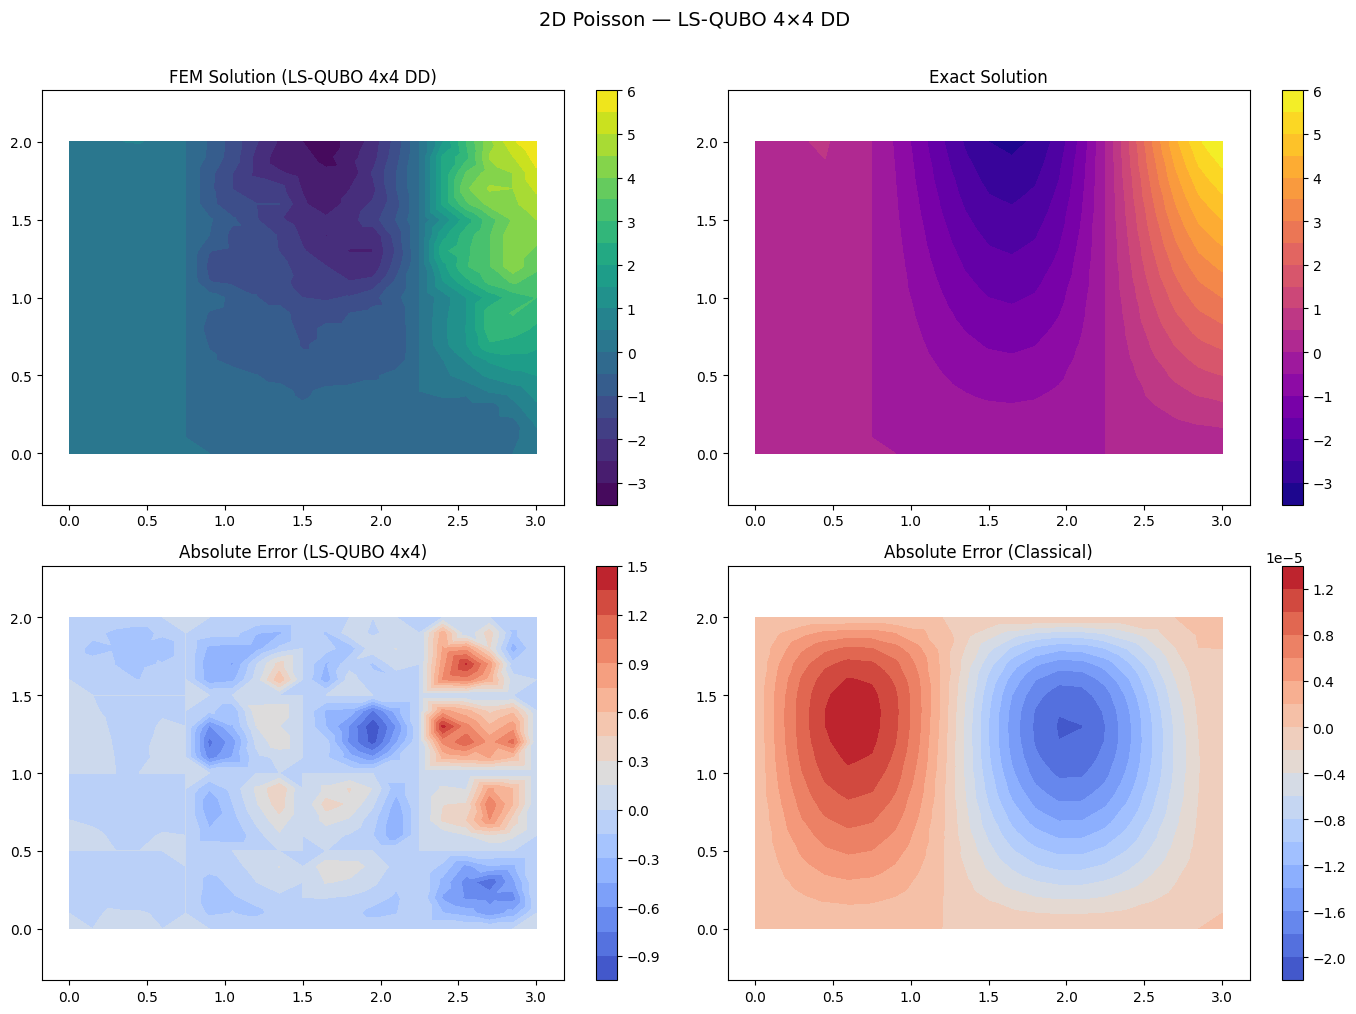

Saved: ls_4x4_result.png


In [47]:
# ===== 可视化 =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im0 = axes[0, 0].tricontourf(nodes[:, 0], nodes[:, 1], u_global, levels=20, cmap='viridis')
axes[0, 0].set_title('FEM Solution (LS-QUBO 4x4 DD)')
axes[0, 0].axis('equal')
fig.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].tricontourf(nodes[:, 0], nodes[:, 1], u_exact_all, levels=20, cmap='plasma')
axes[0, 1].set_title('Exact Solution')
axes[0, 1].axis('equal')
fig.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].tricontourf(nodes[:, 0], nodes[:, 1], error_quantum, levels=20, cmap='coolwarm')
axes[1, 0].set_title('Absolute Error (LS-QUBO 4x4)')
axes[1, 0].axis('equal')
fig.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].tricontourf(nodes[:, 0], nodes[:, 1], error_classical, levels=20, cmap='coolwarm')
axes[1, 1].set_title('Absolute Error (Classical)')
axes[1, 1].axis('equal')
fig.colorbar(im3, ax=axes[1, 1])

fig.suptitle('2D Poisson — LS-QUBO 4×4 DD', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ls_4x4_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ls_4x4_result.png')